<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 160.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 213.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 156.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 158.5 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [6]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [9]:
## Write your code here
# 1. Count the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# 2. Display the first few duplicate rows to understand their structure
duplicate_rows = df[df.duplicated()]
print("\nFirst few duplicate rows:")
print(duplicate_rows.head())

Number of duplicate rows: 20

First few duplicate rows:
       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   
65440           4           I am learning to code     18-24 years old   
65441           5  I am a developer by profession     18-24 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   
65440   Student, full-time        NaN  Apples   
65441   Student, full-time        NaN  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to ope

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [11]:
## Write your code here
# Select the columns to define the "Response Pattern"
# 1.identify duplicate response patterns based on selected columns
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Count occurrences of each combination
pattern_counts = df.groupby(pattern_cols).size().reset_index(name='Respondent_Count')

# Sort to see the most common "duplicate" patterns
common_patterns = pattern_counts.sort_values(by='Respondent_Count', ascending=False)

print("Top 10 Most Common Response Patterns:")
print(common_patterns.head(10))

#2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. 
# Let's analyze the most frequent pattern found above
top_pattern = common_patterns.iloc[0]

# Filter the original dataframe to look ONLY at respondents in this pattern
# (e.g., "I am a developer" + "Employed full-time" + "Remote")
top_group = df[
    (df['MainBranch'] == top_pattern['MainBranch']) & 
    (df['Employment'] == top_pattern['Employment']) & 
    (df['RemoteWork'] == top_pattern['RemoteWork'])
]

# Identify which other columns have identical or highly shared values
sharing_analysis = []
for col in df.columns:
    if col not in pattern_cols:
        # Count how many unique values exist in this group for this column
        unique_values = top_group[col].nunique()
        total_responses = top_group[col].count()
        
        if total_responses > 0:
            sharing_analysis.append({
                'Column': col,
                'Unique_Values': unique_values,
                'Sharing_Degree': 1 - (unique_values / total_responses) # 1.0 = Everyone has the same value
            })

# Display columns where respondents are most likely to share identical values
sharing_df = pd.DataFrame(sharing_analysis).sort_values(by='Sharing_Degree', ascending=False)
print("\nColumns with the most identical values within the top pattern group:")
print(sharing_df.head(10))


Top 10 Most Common Response Patterns:
                                            MainBranch  \
0                       I am a developer by profession   
2                       I am a developer by profession   
1                       I am a developer by profession   
78                      I am a developer by profession   
8                       I am a developer by profession   
232  I am not primarily a developer, but I write co...   
6                       I am a developer by profession   
76                      I am a developer by profession   
233  I am not primarily a developer, but I write co...   
234  I am not primarily a developer, but I write co...   

                                            Employment  \
0                                  Employed, full-time   
2                                  Employed, full-time   
1                                  Employed, full-time   
78   Independent contractor, freelancer, or self-em...   
8    Employed, full-time;Independ

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


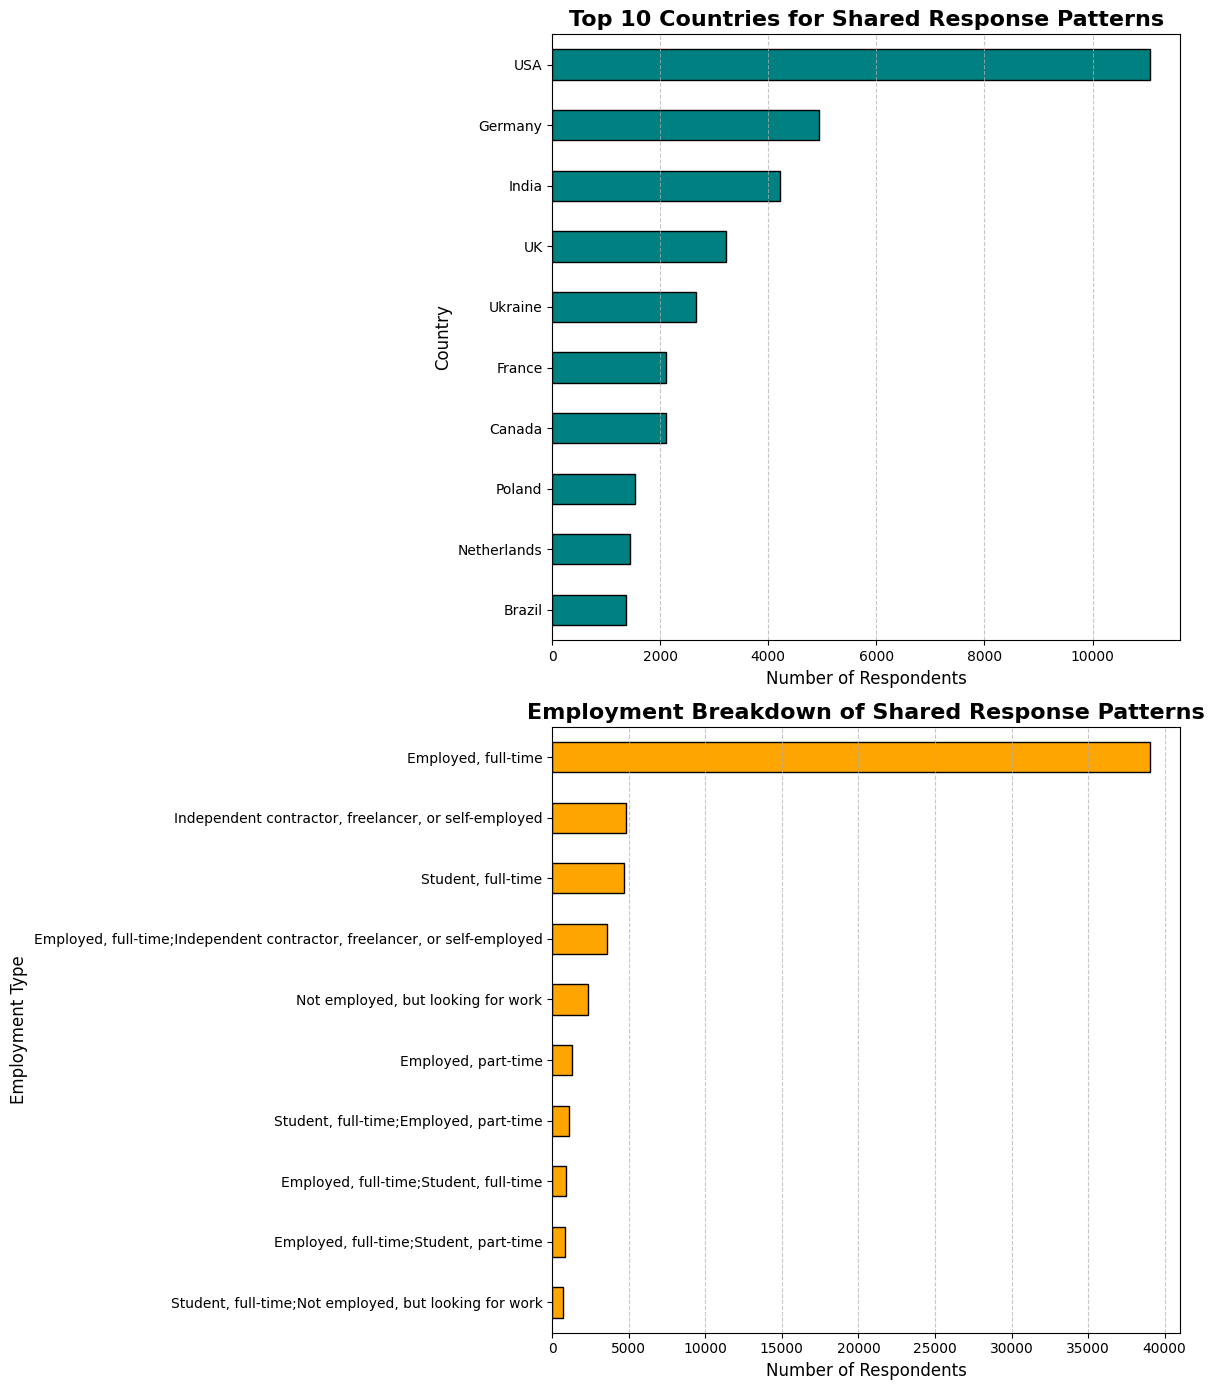

Country labels updated successfully:
Country
USA        11065
Germany     4946
India       4222
UK          3224
Ukraine     2664
Name: count, dtype: int64


In [20]:

# 1. Load the dataset (Assuming 'df' is already loaded)
# Perform the country name rewrite for cleaner labels
df['Country'] = df['Country'].replace({
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK'
})

# 2. Identify all respondents with shared patterns
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']
shared_df = df[df.duplicated(subset=pattern_cols, keep=False)].copy()

# 3. Create a large categorization dashboard with Horizontal Bar Charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

# --- Chart 1: Distribution by Country (Top 10) ---
# Using kind='barh' and inverting the y-axis so the largest is at the top
country_counts = shared_df['Country'].value_counts().head(10)
country_counts.sort_values(ascending=True).plot(kind='barh', ax=ax1, color='teal', edgecolor='black')

ax1.set_title('Top 10 Countries for Shared Response Patterns', fontsize=16, fontweight='bold')
ax1.set_xlabel('Number of Respondents', fontsize=12)
ax1.set_ylabel('Country', fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# --- Chart 2: Distribution by Employment Type ---
employment_counts = shared_df['Employment'].value_counts().head(10)
employment_counts.sort_values(ascending=True).plot(kind='barh', ax=ax2, color='orange', edgecolor='black')

ax2.set_title('Employment Breakdown of Shared Response Patterns', fontsize=16, fontweight='bold')
ax2.set_xlabel('Number of Respondents', fontsize=12)
ax2.set_ylabel('Employment Type', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

# Display check
print("Country labels updated successfully:")
print(shared_df['Country'].value_counts().head(5))

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [22]:
## Write your analysis here
# Check for columns that could serve as a unique identifier
potential_keys = []
total_rows = len(df)

for col in df.columns:
    if df[col].nunique() == total_rows:
        potential_keys.append(col)

print(f"Columns with 100% unique values: {potential_keys}")

# If 'Respondent' exists, verify its uniqueness
if 'Respondent' in df.columns:
    is_unique = df['Respondent'].is_unique
    print(f"Is the 'Respondent' column unique? {is_unique}")

Columns with 100% unique values: []


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


# Write your explanation here
1. Inspection: Peek at the data using df.head() to understand the structure and locate the unique identifier (e.g., Respondent).

2. Identification: Use the df.duplicated() method to flag rows that are exact copies of previous rows.

3. Counting: Apply .sum() to the boolean Series to calculate the total number of duplicate records.

4. Verification: Filter the DataFrame using Boolean Indexing (df[df.duplicated()]) to visually inspect a sample of the duplicates.

5. Removal: Use df.drop_duplicates() to create a cleaned version of the dataset, ensuring that only one instance of each record remains.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


# Write your explanation here
1. We prioritize the unique identifier column (like Respondent) for removal. In survey data, this ID represents a single submission. If this ID repeats, it indicates a technical error (e.g., data was loaded twice), and the record should be removed.
2. We do not remove rows based on a subset of professional categories (like MainBranch, Employment, or RemoteWork).

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
